In [4]:
import pandas as pd
import re
import numpy as np

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns: f000, f001, ..., f127
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

C:\Users\hp\AppData\Local\Temp\ipykernel_33420\1869704404.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_33420\1869704404.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


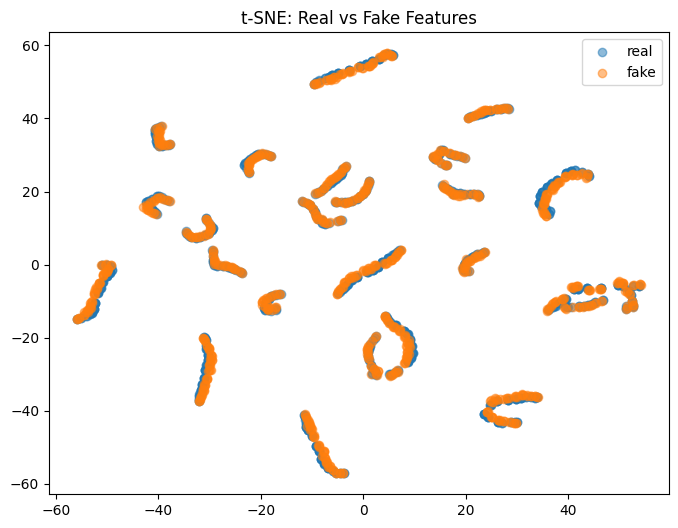

In [2]:
# tsne

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.5)

plt.title("t-SNE: Real vs Fake Features")
plt.legend()
plt.show()

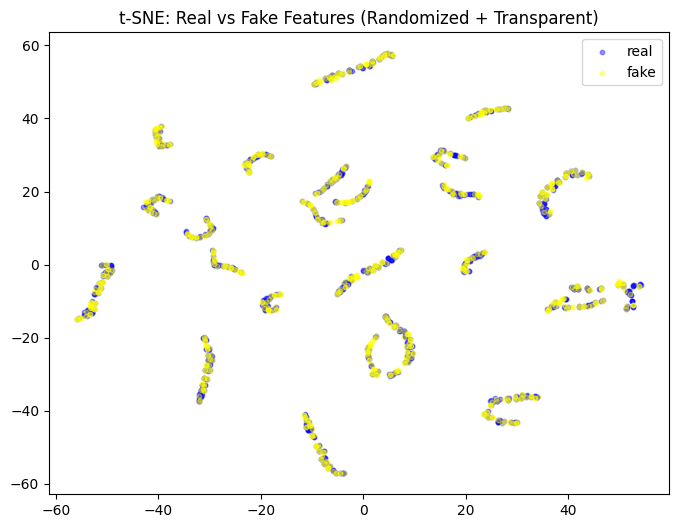

In [6]:
# -----------------------------
# t-SNE
# -----------------------------
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# -----------------------------
# 🔥 RANDOMIZE ORDER
# -----------------------------
perm = np.random.permutation(len(X_tsne))

X_tsne = X_tsne[perm]
y = y[perm]

# -----------------------------
# 🎨 Plot (Yellow & Blue + Transparency)
# -----------------------------
plt.figure(figsize=(8,6))

colors = {"real": "blue", "fake": "yellow"}

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        c=colors[label],
        label=label,
        alpha=0.4,   # semi-transparent
        s=10         # smaller points (better density view)
    )

plt.title("t-SNE: Real vs Fake Features (Randomized + Transparent)")
plt.legend()
plt.show()